# Load-Shedding Business Cost Index

**Author:** Diya Lakha

**Problem statement:** Load-shedding is one of the most disruptive and universally-felt issues facing South African households and small businesses. This project analyses how load-shedding severity has changed over time (2022-2025), quantifies the seasonal pattern, and estimates the financial impact on a typical small business.

**Data:** `data/eskom_stages.csv` - see the README for a full explanation of the data source and assumptions. In short: this is illustrative sample data modelled on publicly reported national trends, built so the full pipeline (SQL -> Python -> visualisation) can be demonstrated end to end. It is designed to be swapped for real EskomSePush API data (see `scripts/fetch_live_data.py`).

**Tools used:** SQLite (SQL), pandas, matplotlib/seaborn.

**Skills demonstrated:** SQL aggregation and window functions, data wrangling with pandas, exploratory data analysis, and clear data storytelling.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

conn = sqlite3.connect("../load_shedding.db")
df = pd.read_sql("SELECT * FROM load_shedding_daily", conn, parse_dates=["date"])
df.head()

,date,year,month,stage,hours_shed,season,est_business_cost_zar
0,2022-01-01,2022,1,3,6.0,summer,5100.0
1,2022-01-02,2022,1,3,6.0,summer,5100.0
2,2022-01-03,2022,1,3,6.0,summer,5100.0
3,2022-01-04,2022,1,4,8.0,summer,6800.0
4,2022-01-05,2022,1,3,6.0,summer,5100.0


## 1. How has severity changed year over year?

This answers the core question: is load-shedding actually getting better or worse?

In [2]:
yearly = pd.read_sql(
    """
    SELECT year,
           ROUND(AVG(stage), 2) AS avg_stage,
           ROUND(SUM(hours_shed), 0) AS total_hours_shed,
           ROUND(SUM(est_business_cost_zar), 0) AS total_est_cost_zar
    FROM load_shedding_daily
    GROUP BY year
    ORDER BY year
    """,
    conn,
)
yearly

,year,avg_stage,total_hours_shed,total_est_cost_zar
0,2022,4.01,2928.0,2488800.0
1,2023,4.81,3508.0,2981800.0
2,2024,1.87,1366.0,1161100.0
3,2025,1.28,932.0,792200.0


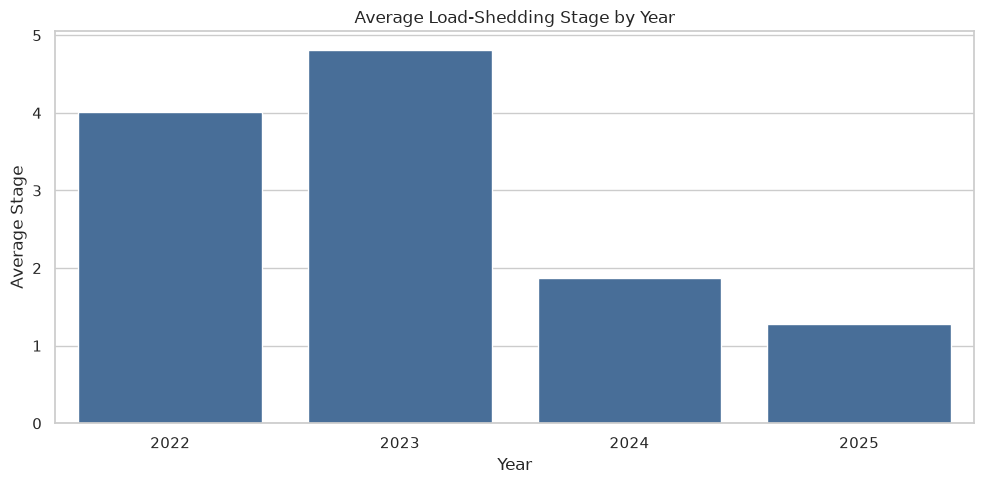

In [3]:
fig, ax = plt.subplots()
sns.barplot(data=yearly, x="year", y="avg_stage", ax=ax, color="#3b6ea5")
ax.set_title("Average Load-Shedding Stage by Year")
ax.set_ylabel("Average Stage")
ax.set_xlabel("Year")
plt.tight_layout()
plt.savefig("../outputs_avg_stage_by_year.png", dpi=150)
plt.show()

## 2. Does load-shedding really get worse in winter?

A common assumption worth actually verifying with data rather than taking as given.

In [4]:
seasonal = pd.read_sql(
    """
    SELECT season, ROUND(AVG(stage), 2) AS avg_stage
    FROM load_shedding_daily
    GROUP BY season
    """,
    conn,
)
seasonal

,season,avg_stage
0,summer,2.59
1,winter,3.77


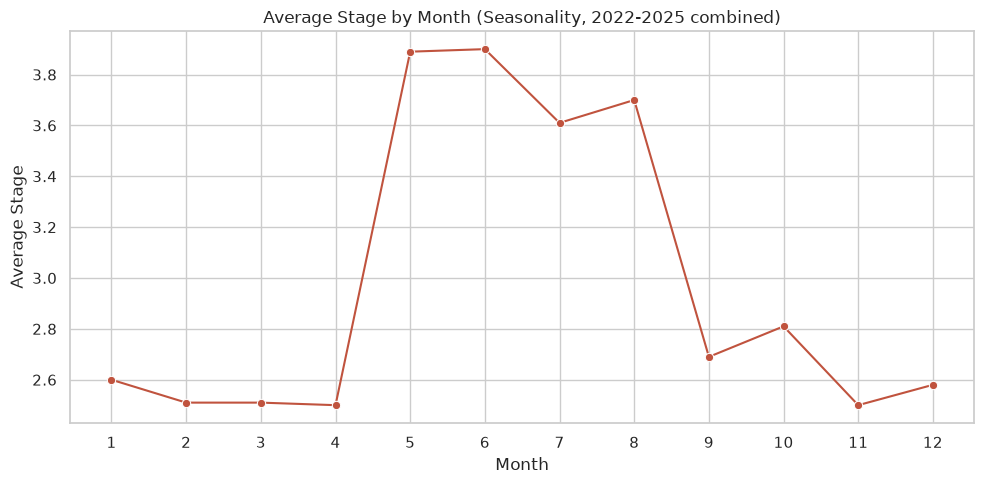

In [5]:
monthly = pd.read_sql(
    """
    SELECT month, ROUND(AVG(stage), 2) AS avg_stage
    FROM load_shedding_daily
    GROUP BY month
    ORDER BY month
    """,
    conn,
)

fig, ax = plt.subplots()
sns.lineplot(data=monthly, x="month", y="avg_stage", marker="o", ax=ax, color="#c0533e")
ax.set_title("Average Stage by Month (Seasonality, 2022-2025 combined)")
ax.set_xticks(range(1, 13))
ax.set_xlabel("Month")
ax.set_ylabel("Average Stage")
plt.tight_layout()
plt.savefig("../outputs_seasonality.png", dpi=150)
plt.show()

## 3. Trend over time: 90-day rolling average

This smooths out day-to-day noise so the underlying trend (improving, worsening, or flat) is easy to see - the same technique used in the SQL window function in `sql/queries.sql`.

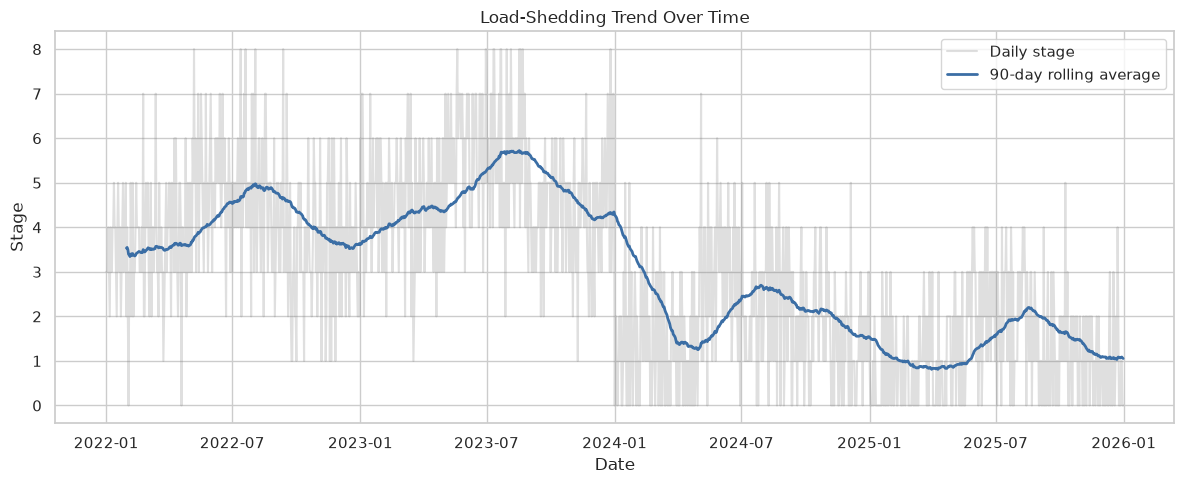

In [6]:
df = df.sort_values("date")
df["rolling_90day_avg"] = df["stage"].rolling(window=90, min_periods=30).mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df["date"], df["stage"], alpha=0.25, color="grey", label="Daily stage")
ax.plot(df["date"], df["rolling_90day_avg"], color="#3b6ea5", linewidth=2, label="90-day rolling average")
ax.set_title("Load-Shedding Trend Over Time")
ax.set_ylabel("Stage")
ax.set_xlabel("Date")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs_trend.png", dpi=150)
plt.show()

## 4. Estimated cost to a small business

Using a documented, adjustable assumption of R850 estimated lost revenue per hour without power (see README) - not presented as a verified real-world figure, but as a transparent way to translate hours-without-power into something a business owner instantly understands.

In [7]:
total_cost = pd.read_sql(
    "SELECT ROUND(SUM(est_business_cost_zar), 0) AS total_cost, ROUND(SUM(hours_shed),0) AS total_hours FROM load_shedding_daily",
    conn,
)
total_cost

,total_cost,total_hours
0,7423900.0,8734.0


## Key findings (fill in after running with your own data)

- Which year was the most severe, and by how much compared to the best year?
- Is the winter-vs-summer difference actually as large as commonly assumed?
- Is the trend line improving, worsening, or flat over the full period?
- What is the estimated total cost to a small business over the period, and per month?

Write 3-4 sentences here summarising what the data actually shows once you've run it - this narrative is what you'll walk an interviewer through, so make sure you can explain *why* each number is what it is.